In [89]:
import pandas
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_predict, cross_val_score
from sklearn.impute import SimpleImputer
from matplotlib.colors import LogNorm
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.compose import ColumnTransformer
from sklearn.naive_bayes import CategoricalNB
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from imblearn.pipeline import Pipeline  
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,roc_curve, auc, precision_score, recall_score, f1_score, precision_recall_fscore_support, ConfusionMatrixDisplay

In [90]:
BLACK = '\033[30m'
RED = '\033[31m'
GREEN = '\033[32m'
YELLOW = '\033[33m' # orange on some systems
BLUE = '\033[34m'
MAGENTA = '\033[35m'
CYAN = '\033[36m'
LIGHT_GRAY = '\033[37m'
DARK_GRAY = '\033[90m'
BRIGHT_RED = '\033[91m'
BRIGHT_GREEN = '\033[92m'
BRIGHT_YELLOW = '\033[93m'
BRIGHT_BLUE = '\033[94m'
BRIGHT_MAGENTA = '\033[95m'
BRIGHT_CYAN = '\033[96m'
RESET = '\033[0m' # called to return to standard terminal text color

def colored_text(color, txt):
    return color + str(txt) + RESET

In [91]:
datasets_path = "data"
years = [2019,2020, 2021, 2022, 2023, 2024]

df_usagers = []

for year in years:
    df_usagers_year = pandas.read_csv(os.path.join(datasets_path, str(year), f"usagers-{year}.csv"), encoding="utf-8", sep = ";")
    df_usagers.append(df_usagers_year)

df_usagers = pandas.concat(df_usagers)
df_usagers

,Num_Acc,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp,id_usager
0,201900000001,138 306 524,B01,2,2,4,2,2002.0,0,1,0,-1,-1,-1,-1,NaN
1,201900000001,138 306 524,B01,1,1,4,2,1993.0,5,1,0,-1,-1,-1,-1,NaN
2,201900000001,138 306 525,A01,1,1,1,1,1959.0,0,1,0,-1,-1,-1,-1,NaN
3,201900000002,138 306 523,A01,1,1,4,2,1994.0,0,1,0,-1,-1,-1,-1,NaN
4,201900000003,138 306 520,A01,1,1,1,1,1996.0,0,1,0,-1,-1,0,-1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125182,202400054401,155 686 119,Y01,1,1,4,2,1978.0,0,0,0,0,-1,-1,-1,203 859 570
125183,202400054401,155 686 120,A01,1,1,1,1,1984.0,0,2,6,0,-1,-1,-1,203 859 572
125184,202400054402,155 686 118,A01,1,1,4,1,1981.0,4,1,0,-1,-1,-1,-1,203 859 569
125185,202400054402,155 686 121,B01,1,1,4,2,1986.0,9,1,0,-1,-1,-1,-1,203 859 571


In [92]:
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  str    
 2   num_veh      745158 non-null  str    
 3   place        745158 non-null  int64  
 4   catu         745158 non-null  int64  
 5   grav         745158 non-null  int64  
 6   sexe         745158 non-null  int64  
 7   an_nais      734040 non-null  float64
 8   trajet       745158 non-null  int64  
 9   secu1        745158 non-null  int64  
 10  secu2        745158 non-null  int64  
 11  secu3        745158 non-null  int64  
 12  locp         745158 non-null  int64  
 13  actp         745158 non-null  str    
 14  etatp        745158 non-null  int64  
 15  id_usager    506886 non-null  str    
dtypes: float64(1), int64(11), str(4)
memory usage: 96.6 MB


In [93]:
df_usagers.drop(columns=["num_veh", "id_usager"] ,inplace=True)

In [94]:
df_usagers["id_vehicule"] = (
    df_usagers["id_vehicule"]
    .astype(str)
    .str.replace(r"\D", "", regex=True)  # keep only digits
    .astype("int64")
)

In [95]:
column_names_to_int = ["place", "catu", "grav", "sexe", "an_nais", "trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

df_usagers[column_names_to_int] = df_usagers[column_names_to_int].apply(
    lambda col: pandas.to_numeric(
        col.astype(str).str.extract(r'(-?\d+)')[0],
        errors="coerce"
    ),
    axis=0 # for each column
)
df_usagers.info()

<class 'pandas.DataFrame'>
Index: 745158 entries, 0 to 125186
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      745158 non-null  int64  
 1   id_vehicule  745158 non-null  int64  
 2   place        745158 non-null  int64  
 3   catu         745158 non-null  int64  
 4   grav         745158 non-null  int64  
 5   sexe         745158 non-null  int64  
 6   an_nais      734040 non-null  float64
 7   trajet       745158 non-null  int64  
 8   secu1        745158 non-null  int64  
 9   secu2        745158 non-null  int64  
 10  secu3        745158 non-null  int64  
 11  locp         745158 non-null  int64  
 12  actp         742496 non-null  float64
 13  etatp        745158 non-null  int64  
dtypes: float64(2), int64(12)
memory usage: 85.3 MB


In [96]:
df_usagers.replace(-1, pandas.NA, inplace=True)
df_usagers["trajet"] = df_usagers["trajet"].replace(0, pandas.NA) # For trajet -1 and 0 mean missing value

for col in df_usagers.columns:
    prop = df_usagers[col].isna().sum() / df_usagers.shape[0]
    print(f"For {colored_text(MAGENTA, col)} proportion missing: {prop * 100:.2f}%")

For Num_Acc proportion missing: 0.00%
For id_vehicule proportion missing: 0.00%
For place proportion missing: 0.00%
For catu proportion missing: 0.00%
For grav proportion missing: 0.06%
For sexe proportion missing: 1.43%
For an_nais proportion missing: 1.49%
For trajet proportion missing: 27.76%
For secu1 proportion missing: 1.34%
For secu2 proportion missing: 40.63%
For secu3 proportion missing: 97.31%
For locp proportion missing: 45.88%
For actp proportion missing: 42.05%
For etatp proportion missing: 92.18%


In [97]:
df_usagers = df_usagers.dropna(subset=["grav","sexe","an_nais", "place", "catu"])

As for secu1, secu2 and secu3 these are important but we have ot convert these into more meaningfull and usable form.

For this, let's see their distribution and how they relate to gravity

In [98]:
equipments = {
    0: "aucun",
    1: "ceinture",
    2: "casque",
    3: "dispositif_enfant",
    4: "gilet_reflechissant",
    5: "airbag",
    6: "gants",
    7: "gants_airbag",
    8: "non determinable",
    9: "autre"
}

def encode_secu(df):
    # Initialize columns EXCEPT gants_airbag
    for name in equipments.values():
        if name != "gants_airbag":
            df[name] = 0

    for col in ["secu1", "secu2", "secu3"]:
        for code, name in equipments.items():
            if name == "gants_airbag":
                # Split into two features
                df.loc[df[col] == code, "gants"] = 1
                df.loc[df[col] == code, "airbag"] = 1
            else:
                df.loc[df[col] == code, name] = 1

    # if any equipment used → aucun = 0
    protection_cols = [c for c in equipments.values() if c not in ["aucun", "gants_airbag"]]
    df.loc[df[protection_cols].sum(axis=1) > 0, "aucun"] = 0

    return df

df_usagers = encode_secu(df_usagers)    
df_usagers.drop(columns=["secu1", "secu2", "secu3"] ,inplace=True)

In [99]:
df_no_protection = df_usagers[
    (df_usagers["aucun"] == 1) &
    (df_usagers["catu"] != 3)
] # hors piétons

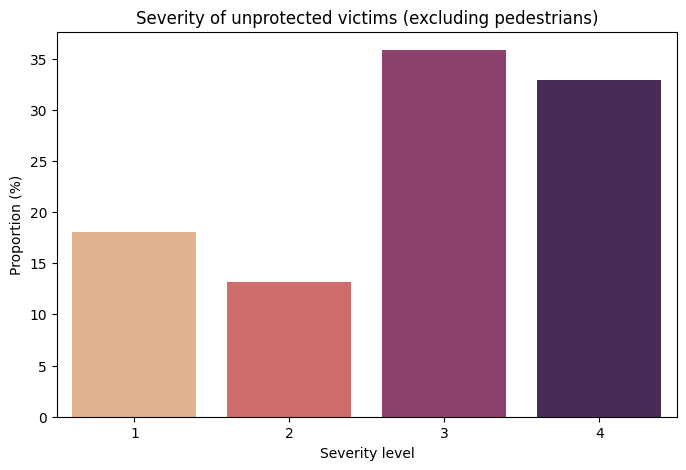

In [100]:
plt.figure(figsize=(8,5))
sns.countplot(
    data=df_no_protection,
    x="grav",
    hue="grav",
    stat="percent",
    palette="flare",
    legend=False
)

plt.title("Severity of unprotected victims (excluding pedestrians)")
plt.xlabel("Severity level")
plt.ylabel("Proportion (%)")
plt.show()

In [101]:
df_usagers["age"] = 2026 - df_usagers["an_nais"]
df_usagers.drop(columns="an_nais", inplace=True)

In [102]:
df_usagers["age"].describe()

count    734019.000000
mean         43.083614
std          19.089808
min           2.000000
25%          28.000000
50%          40.000000
75%          56.000000
max         126.000000
Name: age, dtype: float64

In [103]:
len(df_usagers[df_usagers["age"] > 100])

473

In [104]:
df_usagers[df_usagers["age"] > 100]["age"].value_counts().sort_index()

age
101.0    117
102.0     55
103.0     44
104.0     25
105.0     12
106.0     10
107.0      5
109.0      1
111.0      2
112.0      1
113.0      5
114.0      1
115.0      1
116.0      3
125.0     43
126.0    148
Name: count, dtype: int64

In [105]:
df_usagers = df_usagers[df_usagers["age"] <= 100]

<Axes: xlabel='age', ylabel='Count'>

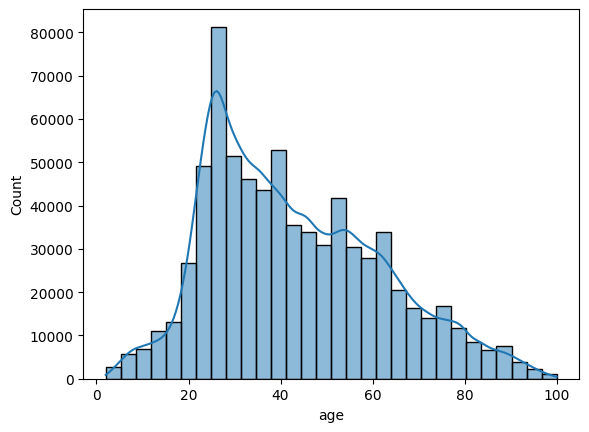

In [106]:
sns.histplot(df_usagers["age"], bins=30, kde=True) 

In [107]:
# On va aussi ajouter une colonne accident grave ou non pour faire une classification binaire, ca sera notre target
df_usagers["grav_bin"] = df_usagers["grav"].replace({
    1: 0,  # Non grave
    4: 0,  # Non grave
    2: 1,  # Grave
    3: 1   # Grave
})

In [108]:
mapping = {
    0: "Not severly injured",
    1: "Severly injured"
}

counts = df_usagers["grav_bin"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Not severly injured proportion: 81.71%
For Severly injured proportion: 18.29%


In [109]:
mapping = {
    1: "Unharmed",
    2: "Killed",
    3: "Hospitalized injury",
    4: "Minor injury"
}

counts = df_usagers["grav"].value_counts()
counts.index = counts.index.map(mapping)

for cl, prop in counts.items():
    print(f"For {colored_text(MAGENTA, cl)} proportion: {prop / len(df_usagers) * 100:.2f}%")

For Unharmed proportion: 41.28%
For Minor injury proportion: 40.44%
For Hospitalized injury proportion: 15.58%
For Killed proportion: 2.70%


In [110]:
df_usagers.columns

Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'trajet',
       'locp', 'actp', 'etatp', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants',
       'non determinable', 'autre', 'age', 'grav_bin'],
      dtype='str')

In [111]:
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "gants", "autre", "grav_bin", "non determinable", "grav"]


In [112]:
df_usagers[cols_int].isna().sum()

place                  0
catu                   0
sexe                   0
age                    0
aucun                  0
ceinture               0
casque                 0
dispositif_enfant      0
gilet_reflechissant    0
airbag                 0
gants                  0
autre                  0
grav_bin               0
non determinable       0
grav                   0
dtype: int64

In [113]:
cols_int = ["place", "catu", "sexe", "age", "aucun", "ceinture", "casque", "dispositif_enfant", "gilet_reflechissant", "airbag", "non determinable", "gants", "autre", "grav_bin", "grav"]
df_usagers[cols_int] = df_usagers[cols_int].astype("int64")

In [114]:
df_usagers.columns

Index(['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'trajet',
       'locp', 'actp', 'etatp', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants',
       'non determinable', 'autre', 'age', 'grav_bin'],
      dtype='str')

In [115]:
features = ['place', 'catu', 'sexe', 'age', 
       'aucun', 'ceinture', 'casque', 'dispositif_enfant',
       'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]


binary_features = ['aucun', 'ceinture', 'casque', 'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"]
numerical_features = ["age"]
categorical_features = list(set(features) - set(binary_features) - set(numerical_features))

target = 'grav_bin'

In [116]:
df_usagers_analyse = df_usagers.copy()

mapping = {
    0: "Absent",
    1: "Present"
}
pres_abs_features = [
    'aucun', 'ceinture', 'casque', 'dispositif_enfant',
    'gilet_reflechissant', 'airbag', 'gants', 'autre', "non determinable"
]
df_usagers_analyse[pres_abs_features] = df_usagers_analyse[pres_abs_features].replace(mapping)

mapping = {
    1: "Driver",
    2: "Front right passenger",
    3: "Rear right passenger",
    4: "Rear left passenger",
    5: "Front left passenger",
    6: "Other seat in light vehicle",
    7: "Public transport – seated",
    8: "Public transport – standing",
    9: "Other public transport",
    10: "Pedestrian (not applicable)"
}

df_usagers_analyse["place"] = df_usagers_analyse["place"].replace(mapping)

mapping = {
    1: "Driver",
    2: "Passenger",
    3: "Pedestrian"
}
df_usagers_analyse["catu"] = df_usagers_analyse["catu"].replace(mapping)

mapping = {
    1: "Male",
    2: "Female"
}
df_usagers_analyse["sexe"] = df_usagers_analyse["sexe"].replace(mapping)

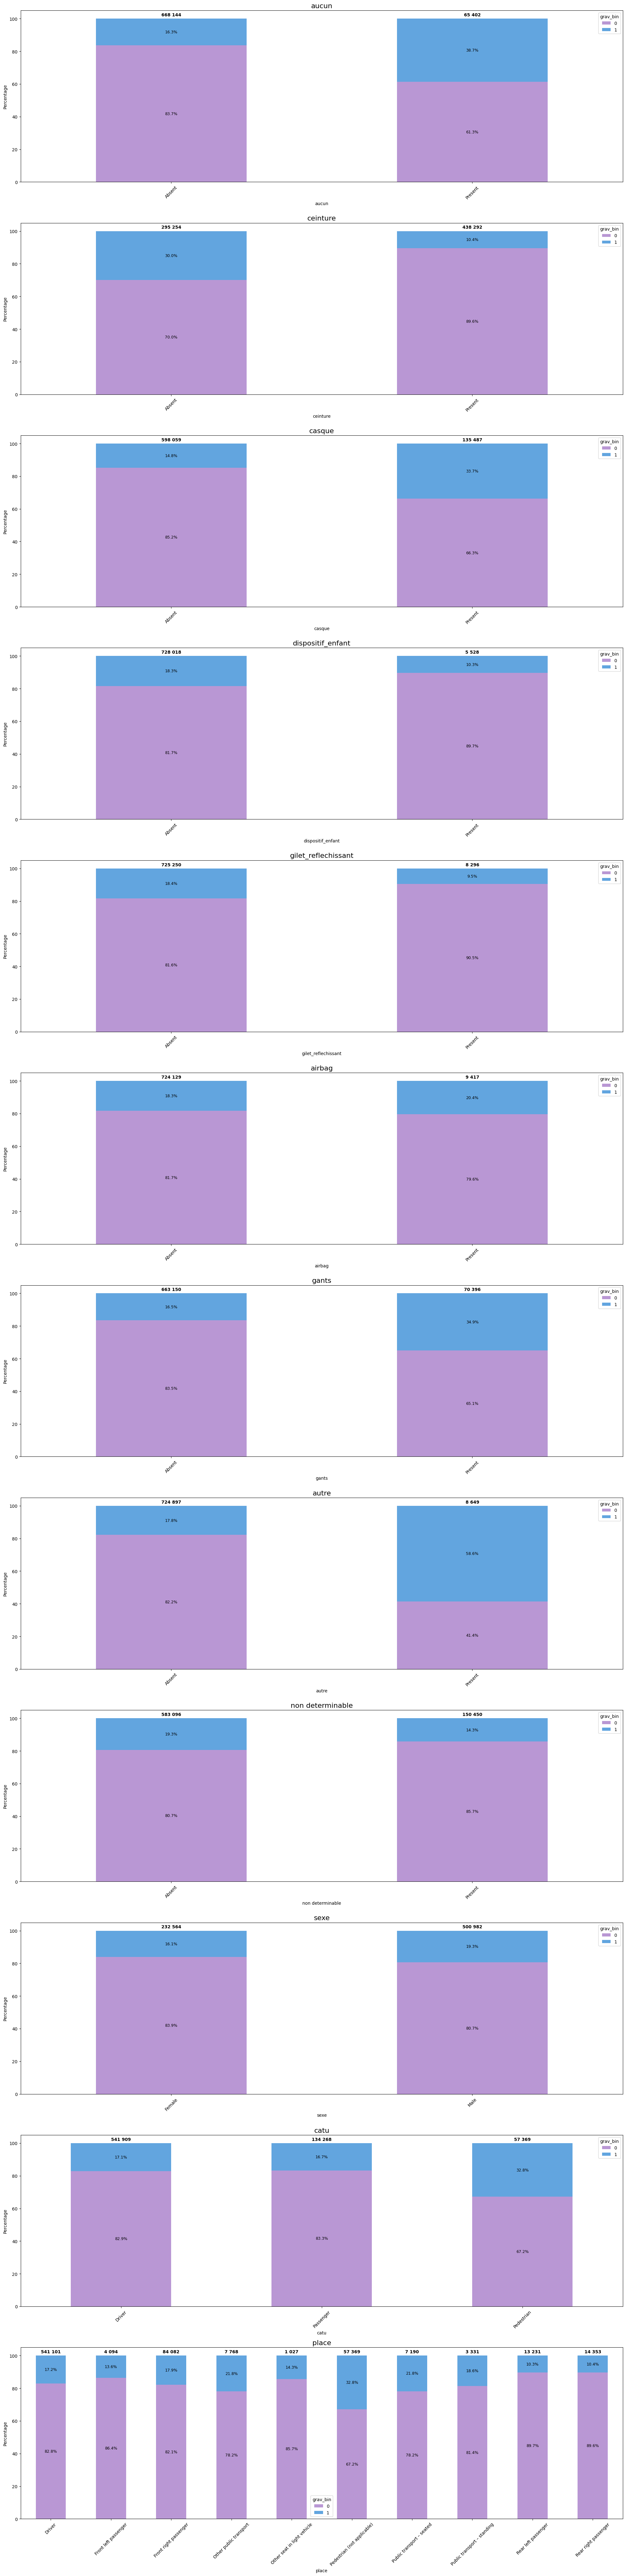

In [117]:
features_to_analyse = binary_features + categorical_features

fig, ax = plt.subplots(len(features_to_analyse), 1, figsize=(20, 6*len(features_to_analyse) + 10))

df_usagers_analyse = df_usagers_analyse.reset_index(drop=True)

for i, feature in enumerate(features_to_analyse):
    ct = pandas.crosstab(
        df_usagers_analyse[feature],
        df_usagers_analyse[target],
        normalize="index"
    ) * 100

    counts = df_usagers_analyse[feature].value_counts().sort_index()

    # Plot
    ct.plot(kind="bar", stacked=True, ax=ax[i], color=["#B997D4", "#62A5DF"])

    # Add % labels inside bars
    for j, category in enumerate(ct.index):
        cumulative = 0
        for k, col in enumerate(ct.columns):
            value = ct.loc[category, col]
            if value > 3:  # avoid clutter for tiny values
                ax[i].text(
                    j,
                    cumulative + value / 2,
                    f"{value:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += value

    # Add total count above bars
    for j, category in enumerate(ct.index):
        ax[i].text(
            j,
            101,  # slightly above 100%
            f"{counts[category]:,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

    ax[i].set_title(feature, fontsize=16)
    ax[i].tick_params(axis='x', rotation=45)
    ax[i].set_ylabel("Percentage")

plt.tight_layout()

In [118]:
import pandas as pd

output_lines = []

for feature in features_to_analyse:
    # Count per class
    counts = df_usagers_analyse.groupby(feature)[target].value_counts().unstack(fill_value=0)
    
    # Proportions (in %)
    proportions = counts.div(counts.sum(axis=1), axis=0) * 100

    # Ensure column order (adapt if needed)
    # Assuming: 0 = not severe, 1 = severe
    for i, category in enumerate(counts.index):
        count = counts.loc[category].sum()
        not_severe = proportions.loc[category].get(0, 0)
        severe = proportions.loc[category].get(1, 0)

        if i == 0:
            line = f"\\texttt{{{feature}}} & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"
        else:
            line = f" & {category} & {count:,} & {not_severe:.1f} & {severe:.1f} \\\\"

        # Replace commas for LaTeX formatting (French style spacing)
        line = line.replace(",", " ")

        output_lines.append(line)

    output_lines.append("\\hline")

# Print result
print("\n".join(output_lines))

\texttt{aucun} & Absent & 668 144 & 83.7 & 16.3 \\
 & Present & 65 402 & 61.3 & 38.7 \\
\hline
\texttt{ceinture} & Absent & 295 254 & 70.0 & 30.0 \\
 & Present & 438 292 & 89.6 & 10.4 \\
\hline
\texttt{casque} & Absent & 598 059 & 85.2 & 14.8 \\
 & Present & 135 487 & 66.3 & 33.7 \\
\hline
\texttt{dispositif_enfant} & Absent & 728 018 & 81.7 & 18.3 \\
 & Present & 5 528 & 89.7 & 10.3 \\
\hline
\texttt{gilet_reflechissant} & Absent & 725 250 & 81.6 & 18.4 \\
 & Present & 8 296 & 90.5 & 9.5 \\
\hline
\texttt{airbag} & Absent & 724 129 & 81.7 & 18.3 \\
 & Present & 9 417 & 79.6 & 20.4 \\
\hline
\texttt{gants} & Absent & 663 150 & 83.5 & 16.5 \\
 & Present & 70 396 & 65.1 & 34.9 \\
\hline
\texttt{autre} & Absent & 724 897 & 82.2 & 17.8 \\
 & Present & 8 649 & 41.4 & 58.6 \\
\hline
\texttt{non determinable} & Absent & 583 096 & 80.7 & 19.3 \\
 & Present & 150 450 & 85.7 & 14.3 \\
\hline
\texttt{sexe} & Female & 232 564 & 83.9 & 16.1 \\
 & Male & 500 982 & 80.7 & 19.3 \\
\hline
\texttt{catu}

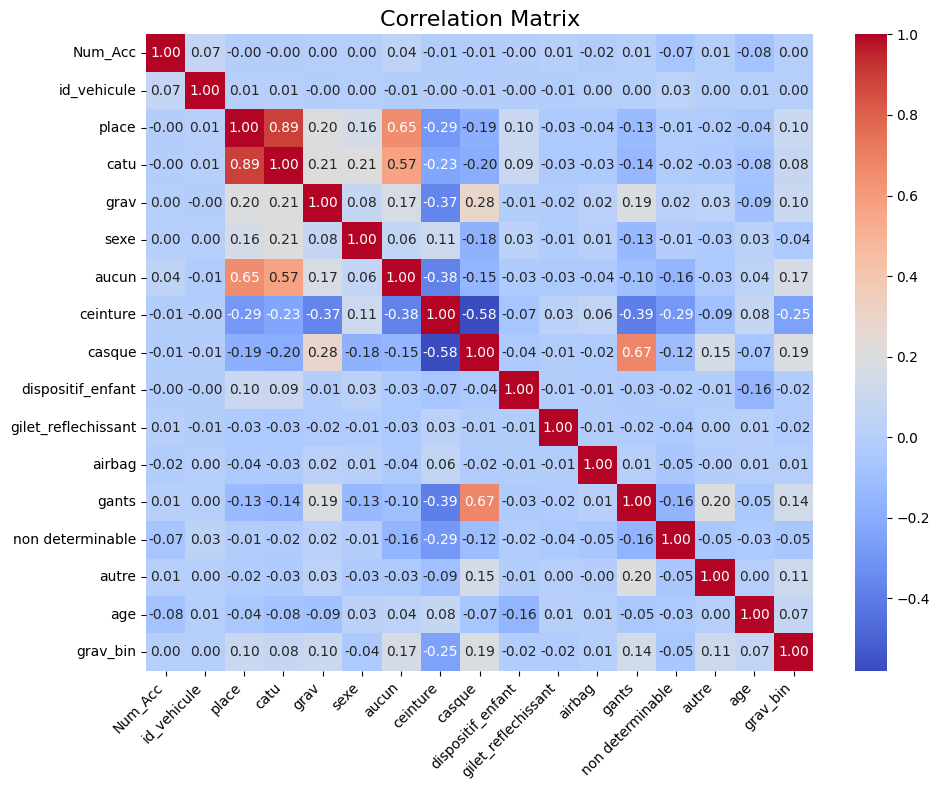

In [119]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    df_usagers[['Num_Acc', 'id_vehicule', 'place', 'catu', 'grav', 'sexe', 'aucun', 'ceinture', 'casque',
       'dispositif_enfant', 'gilet_reflechissant', 'airbag', 'gants', 'non determinable',
       'autre', 'age', 'grav_bin']].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10}
)

plt.title("Correlation Matrix", fontsize=16)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [120]:
binary_features = [
    'aucun', 'ceinture', 'casque', 'dispositif_enfant',
    'gilet_reflechissant', 'airbag', 'gants', 'autre', 'non determinable'
]
numerical_features = ["age"]
categorical_features = list(
    set(features) - set(binary_features) - set(numerical_features))

In [121]:
X = df_usagers[features]
y = df_usagers[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_usagers[target]
)

In [122]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features),
        ("bin", "passthrough", binary_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines_over = {}
pipelines_under = {}
for name, model in models.items():
    pipelines_over[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomOverSampler(random_state=42)),
        ("model", model)
    ])
    pipelines_under[name] = Pipeline([
        ("preprocessing", preprocessor),
        ("sampling", RandomUnderSampler(random_state=42)),
        ("model", model)
    ])

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec over-sampling"))
for name, pipe in pipelines_over.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

print(colored_text(BRIGHT_BLUE, "Evaluation des modèles avec under-sampling"))
for name, pipe in pipelines_under.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

Evaluation des modèles avec over-sampling

 Logistic Regression
Precision: 0.3298206991269749
Recall: 0.6087434647679935
F1: 0.4278369084656951
Accuracy: 0.7022847950705138
              precision    recall  f1-score   support

           0       0.89      0.72      0.80    479533
           1       0.33      0.61      0.43    107303

    accuracy                           0.70    586836
   macro avg       0.61      0.67      0.61    586836
weighted avg       0.79      0.70      0.73    586836


 Decision Tree
Precision: 0.325394103068279
Recall: 0.627689812959563
F1: 0.4286014279714406
Accuracy: 0.6939758297036992
              precision    recall  f1-score   support

           0       0.89      0.71      0.79    479533
           1       0.33      0.63      0.43    107303

    accuracy                           0.69    586836
   macro avg       0.61      0.67      0.61    586836
weighted avg       0.79      0.69      0.72    586836


 Gradient Boosting
Precision: 0.3301433124057783


Now we will study more the pedestrian category (piéton) :

The attributes place and catu ( catégorie de l'usager ) are always known. When catu = 3 (piéton) place must be equal 10 (non applicable pour le piéton) and vice versa .

we notice that we have one incorrect example we don't take it into consideration 

In [123]:
# 2. Détection des incohérences
incoherences = df_usagers[
    ((df_usagers["place"] == 10) & (df_usagers["catu"] != 3)) |
    ((df_usagers["catu"] == 3) & (df_usagers["place"] != 10))
]

print("Number of inconsistent examples : ",  incoherences.shape[0])

df_usagers.drop(incoherences.index, inplace=True) 



Number of inconsistent examples :  0


In [124]:
df_pedestrians = df_usagers[df_usagers["catu"] == 3]

In [125]:
features_pedestrians = [ 'sexe',
       'locp', 'actp', 'etatp', 'age',"aucun", "gilet_reflechissant", 'autre', 'non determinable']
target = "grav_bin"
df_pedestrians_n = df_pedestrians.dropna(subset=features_pedestrians)

In [126]:
df_pedestrians_n[binary_features].sum()

aucun                  43036
ceinture                   0
casque                     0
dispositif_enfant          0
gilet_reflechissant      251
airbag                     0
gants                      0
autre                    155
non determinable       10588
dtype: int64

In [127]:
numerical_features = ["age"]
binary_features = ["aucun", "gilet_reflechissant", 'autre', 'non determinable' ]
categorical_features = list(
    set(features_pedestrians) - set(numerical_features) - set(binary_features))


In [128]:
X = df_pedestrians_n[features_pedestrians]
y = df_pedestrians_n[target]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=df_pedestrians_n[target]
)

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numerical_features)
    ]
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

pipelines = {
    name: Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    for name, model in models.items()
}

for name, pipe in pipelines.items():
    y_pred = cross_val_predict(pipe, X_train, y_train, cv=5) # un label prédit pour chaque exemple de X_train
    
    precision = precision_score(y_train,y_pred)
    recall = recall_score(y_train, y_pred)
    f1 = f1_score(y_train,y_pred)
    accuracy = accuracy_score(y_train, y_pred)

    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_train, y_pred))

TypeError: got an unexpected keyword argument 'scoring'

In [130]:
X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size = .2)
for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_val) # un label prédit pour chaque exemple de X_train
    
    precision, recall, f1, _ = precision_recall_fscore_support(y_val, y_pred, average="binary")
    print("\n", name)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1:", f1)
    print("Accuracy:", accuracy)

    print(classification_report(y_val, y_pred))


 Logistic Regression
Precision: 0.5590909090909091
Recall: 0.17366749029297565
F1: 0.26501481281982225
Accuracy: 0.6949113409678611
              precision    recall  f1-score   support

           0       0.70      0.93      0.80      5830
           1       0.56      0.17      0.27      2833

    accuracy                           0.68      8663
   macro avg       0.63      0.55      0.53      8663
weighted avg       0.65      0.68      0.62      8663


 Decision Tree
Precision: 0.7191358024691358
Recall: 0.41122484998235087
F1: 0.523242757691444
Accuracy: 0.6949113409678611
              precision    recall  f1-score   support

           0       0.76      0.92      0.84      5830
           1       0.72      0.41      0.52      2833

    accuracy                           0.75      8663
   macro avg       0.74      0.67      0.68      8663
weighted avg       0.75      0.75      0.73      8663


 Gradient Boosting
Precision: 0.5764258555133079
Recall: 0.2675608895164137
F1: 0.36547

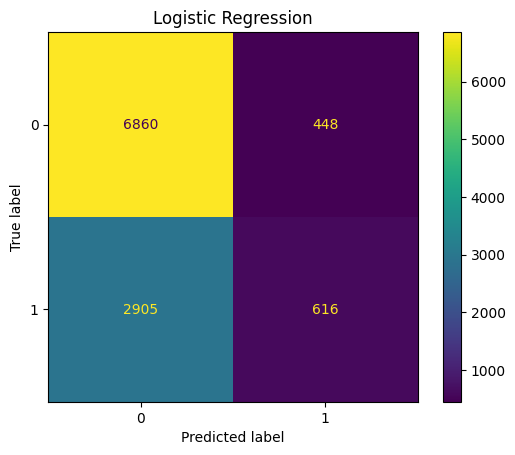

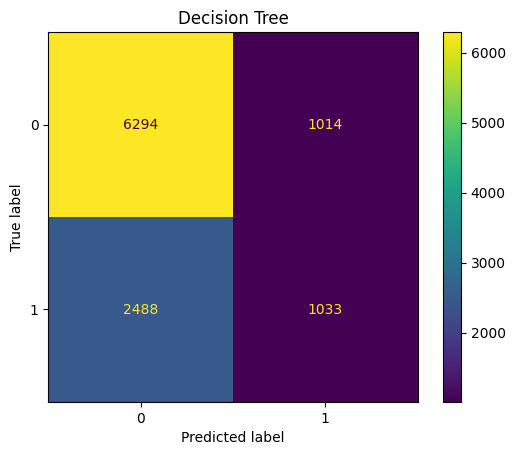

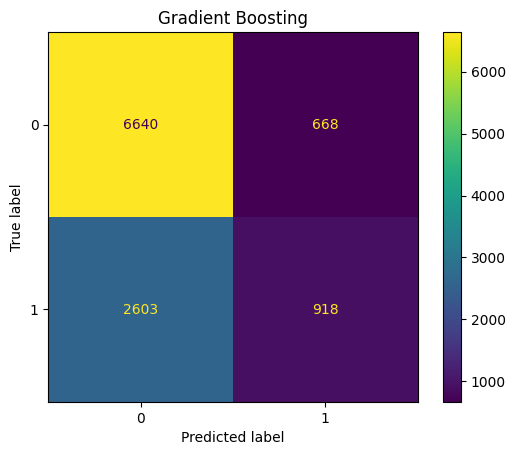

In [131]:
for name, model in pipelines.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title(name)
    plt.show()

In [132]:
# Finally we are going to save the dataset cleaned
df_usagers.to_csv("df_usagers_clean.csv", index=False)